## Feature Engineering

In [3]:
%pip install pandas numpy torch scikit-learn seaborn

  Using cached pandas-3.0.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached torch-2.10.0-3-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_bindings-12.9.4-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv', delimiter=",")

In [3]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,17089,2012-12-19,4,1,12,19,0,3,1,1,0.38,0.3939,0.50,0.3881,7,329,336
10882,17090,2012-12-19,4,1,12,20,0,3,1,1,0.36,0.3485,0.57,0.2239,10,231,241
10883,17091,2012-12-19,4,1,12,21,0,3,1,1,0.34,0.3182,0.61,0.2239,4,164,168
10884,17092,2012-12-19,4,1,12,22,0,3,1,1,0.34,0.3485,0.61,0.0896,12,117,129


In [3]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [4]:
train=df.sample(frac=0.8,random_state=200) #random state is a seed value
validate=df.drop(train.index)
test_df = pd.read_csv("evaluation_data.csv")

In [11]:
train.info()

<class 'pandas.DataFrame'>
Index: 8709 entries, 4396 to 1889
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     8709 non-null   int64  
 1   dteday      8709 non-null   str    
 2   season      8709 non-null   int64  
 3   yr          8709 non-null   int64  
 4   mnth        8709 non-null   int64  
 5   hr          8709 non-null   int64  
 6   holiday     8709 non-null   int64  
 7   weekday     8709 non-null   int64  
 8   workingday  8709 non-null   int64  
 9   weathersit  8709 non-null   int64  
 10  temp        8709 non-null   float64
 11  atemp       8709 non-null   float64
 12  hum         8709 non-null   float64
 13  windspeed   8709 non-null   float64
 14  casual      8709 non-null   int64  
 15  registered  8709 non-null   int64  
 16  cnt         8709 non-null   int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 1.2 MB


In [7]:
train.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000
mean,8497.136066,2.500746,0.499139,6.498794,11.485704,0.028476,2.989666,0.681020,1.418762,0.494155,0.473735,0.620916,0.190857,35.791250,154.125502,189.916753
std,5028.650627,1.115476,0.500028,3.441272,6.924502,0.166339,2.005993,0.466108,0.633777,0.189970,0.169376,0.191881,0.122238,49.708418,150.568113,180.627690
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.015200,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4261.000000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.470000,0.104500,4.000000,36.000000,42.000000
50%,8351.000000,3.000000,0.000000,7.000000,11.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.620000,0.194000,16.000000,116.000000,143.000000
75%,12733.000000,3.000000,1.000000,9.000000,17.000000,0.000000,5.000000,1.000000,2.000000,0.640000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17093.000000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,3.000000,1.000000,0.893900,1.000000,0.850700,367.000000,886.000000,977.000000


In [5]:
print(train["yr"].value_counts())
print(train["mnth"].value_counts())
print(train["weathersit"].value_counts())

yr
0    4362
1    4347
Name: count, dtype: int64
mnth
5     743
8     737
10    736
7     733
2     731
9     731
4     722
3     718
1     717
12    715
6     714
11    712
Name: count, dtype: int64
weathersit
1    5751
2    2269
3     689
Name: count, dtype: int64


In [8]:
train.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [6]:
train = train.drop(columns=['dteday', 'registered', 'casual', 'instant'])
validate = validate.drop(columns=['dteday', 'registered', 'casual', 'instant'])
test = test_df.drop(columns=['dteday'])

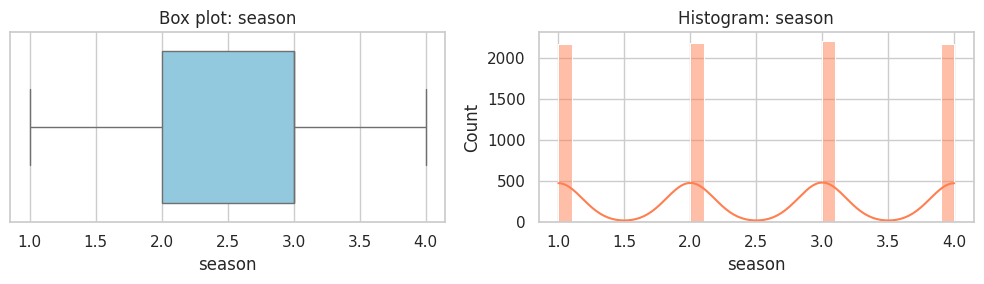

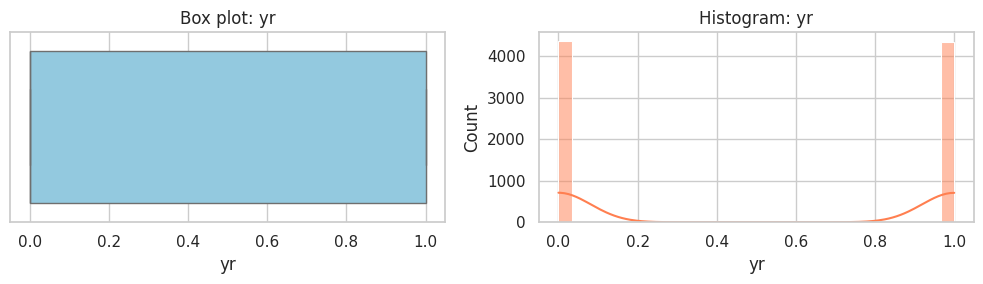

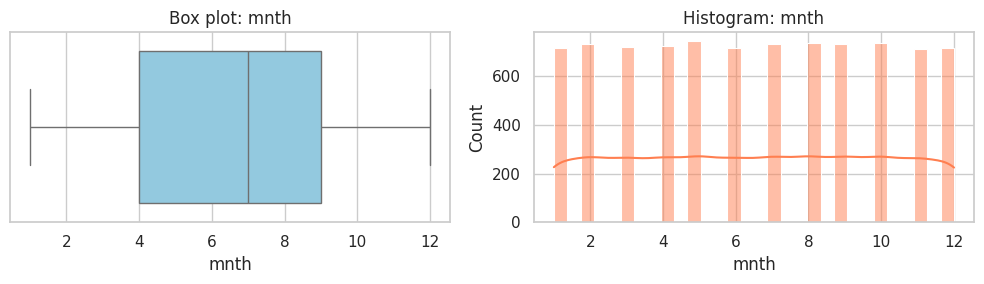

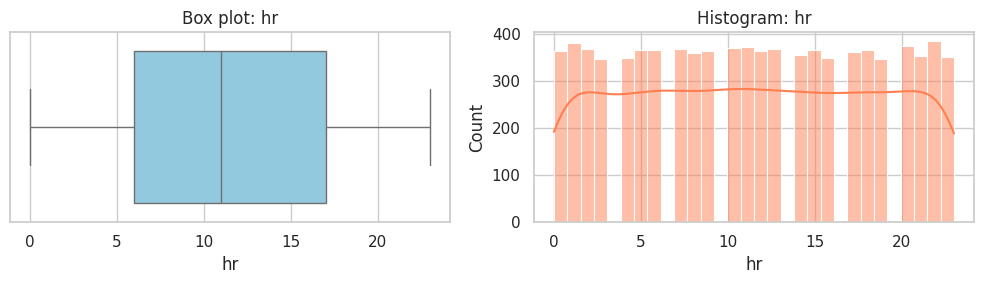

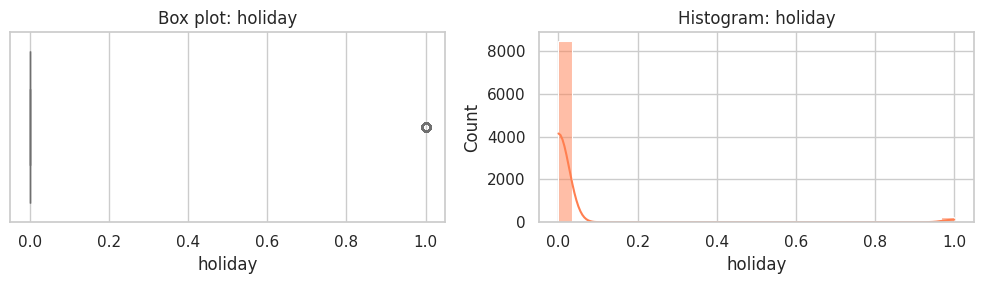

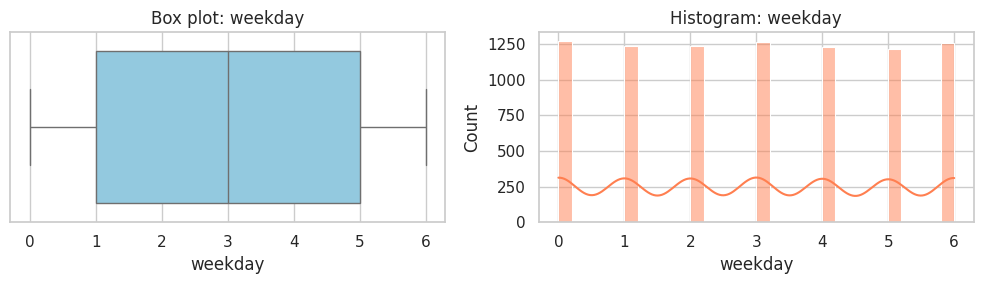

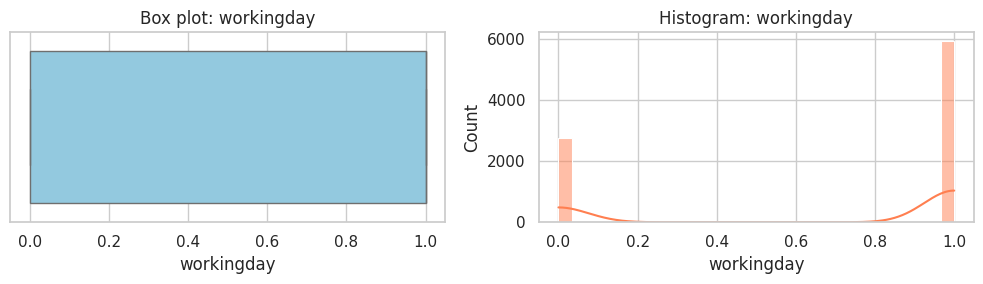

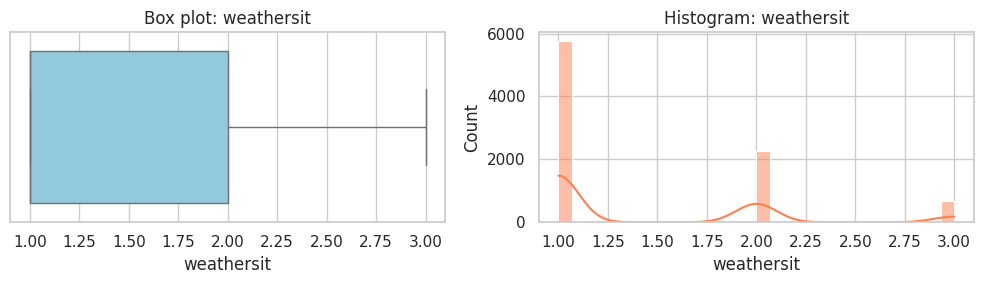

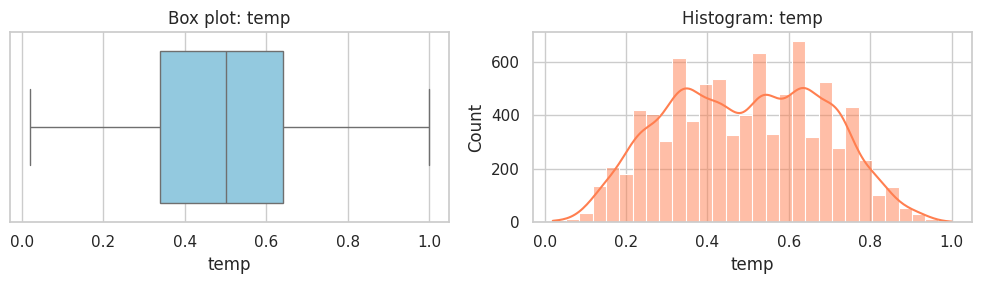

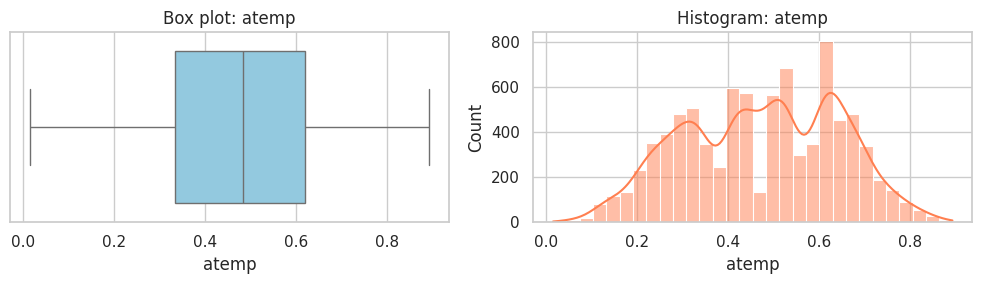

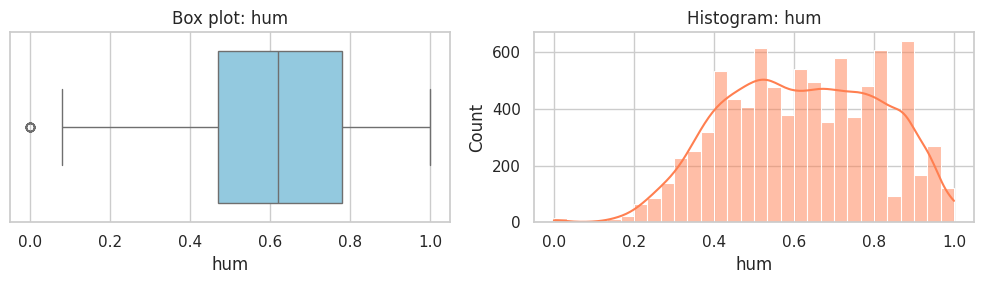

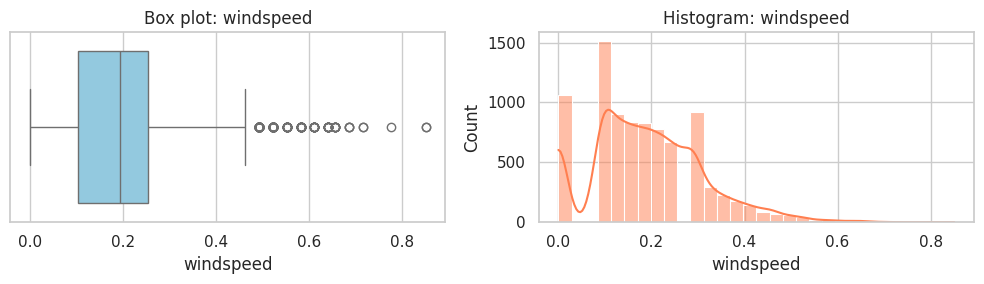

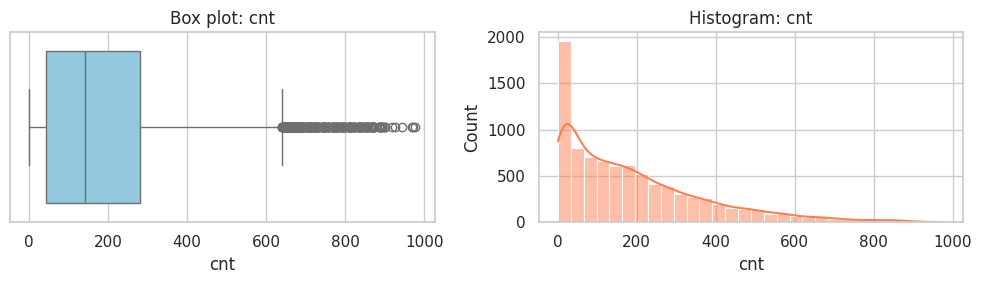

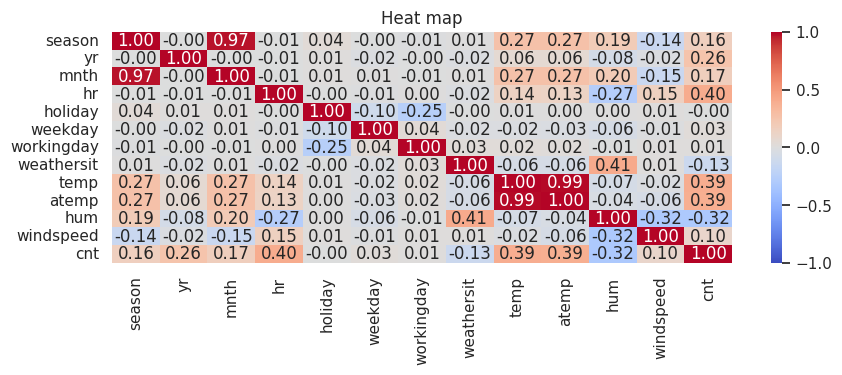

In [7]:
sns.set_theme(style="whitegrid")
columns = train.select_dtypes(include=['float64', 'int64']).columns


for feature in columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Boxplot
    sns.boxplot(data=train, x=feature, color='skyblue', ax=axes[0])
    axes[0].set_title(f'Box plot: {feature}')

    # Histogram
    sns.histplot(data=train, x=feature, bins=30, kde=True, color='coral', ax=axes[1])
    axes[1].set_title(f'Histogram: {feature}')

    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 3))
corr = train.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heat map')
plt.show()

In [8]:
class DataPreparator:
    def __init__(self, replace_outliers=True):
        self.replace_outliers = replace_outliers
        self.lower_bound = {}
        self.upper_bound = {}
        self.X_mean = None
        self.X_std = None
        self.columns_to_drop = ['atemp', 'mnth']
        self.continuous_cols = ['temp', 'hum', 'windspeed']
        self.skewed_cols = ['windspeed']
        self.target_col = 'cnt'

    def fit(self, df_train):
        X_train = df_train.drop(columns=[self.target_col] + self.columns_to_drop, errors='ignore')

        for col in self.continuous_cols:
            if col in X_train.columns:
                Q1 = X_train[col].quantile(0.25)
                Q3 = X_train[col].quantile(0.75)
                IQR = Q3 - Q1
                self.lower_bound[col] = Q1 - 1.5 * IQR
                self.upper_bound[col] = Q3 + 1.5 * IQR

        X_clean = X_train.copy()

        if self.replace_outliers:
            for col in self.continuous_cols:
                if col in X_clean.columns:
                    X_clean[col] = X_clean[col].clip(lower=self.lower_bound[col], upper=self.upper_bound[col])

        for col in self.skewed_cols:
            if col in X_clean.columns:
                X_clean[col] = np.log(X_clean[col] + 1e-5)

        self.X_mean = X_clean.mean(axis=0).values
        self.X_std = X_clean.std(axis=0).values

    def transform(self, df, is_train=False, has_y=True):
        df_processed = df.copy()

        X_df = df_processed.drop(columns=[self.target_col] + self.columns_to_drop, errors='ignore')
        if has_y:
            y = df_processed[self.target_col].values.reshape(-1, 1)
        else:
            y = None

        if self.replace_outliers:
            for col in self.continuous_cols:
                if col in X_df.columns:
                    X_df[col] = X_df[col].clip(lower=self.lower_bound[col], upper=self.upper_bound[col])

        for col in self.skewed_cols:
            if col in X_df.columns:
                X_df[col] = np.log(X_df[col] + 1e-5)

        X_scaled = (X_df.values - self.X_mean) / self.X_std

        return X_scaled, y

In [9]:
preparator = DataPreparator(replace_outliers=True)
preparator.fit(train)

In [10]:
X_train_scaled, y_train_mapped = preparator.transform(train, is_train=True)
X_val_scaled, y_val_mapped = preparator.transform(validate, is_train=False)
X_test_scaled, y_test_mapped = preparator.transform(test, is_train=False, has_y=False)

input_dimensions = X_train_scaled.shape[1]

tensor_X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train_mapped, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val_mapped, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
validation_dataset = TensorDataset(tensor_X_val, tensor_y_val)
test_dataset = TensorDataset(tensor_X_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Model

In [ ]:
from model import Network, train_model, evaluate, calc_accuracy, torch_rmsle

## Train

Epoch [10/1000], Loss: 2.1337
Epoch [20/1000], Loss: 1.8212
Epoch [30/1000], Loss: 1.6873
Epoch [40/1000], Loss: 1.6119
Epoch [50/1000], Loss: 1.5648
Epoch [60/1000], Loss: 1.5293
Epoch [70/1000], Loss: 1.5059
Epoch [80/1000], Loss: 1.4883
Epoch [90/1000], Loss: 1.4730
Epoch [100/1000], Loss: 1.4660
Epoch [110/1000], Loss: 1.4537
Epoch [120/1000], Loss: 1.4516
Epoch [130/1000], Loss: 1.4422
Epoch [140/1000], Loss: 1.4357
Epoch [150/1000], Loss: 1.4320
Epoch [160/1000], Loss: 1.4301
Epoch [170/1000], Loss: 1.4250
Epoch [180/1000], Loss: 1.4228
Epoch [190/1000], Loss: 1.4215
Epoch [200/1000], Loss: 1.4167
Epoch [210/1000], Loss: 1.4166
Epoch [220/1000], Loss: 1.4154
Epoch [230/1000], Loss: 1.4142
Epoch [240/1000], Loss: 1.4110
Epoch [250/1000], Loss: 1.4136
Epoch [260/1000], Loss: 1.4117
Epoch [270/1000], Loss: 1.4111
Epoch [280/1000], Loss: 1.4088
Epoch [290/1000], Loss: 1.4093
Epoch [300/1000], Loss: 1.4110
Epoch [310/1000], Loss: 1.4082
Epoch [320/1000], Loss: 1.4095
Epoch [330/1000],

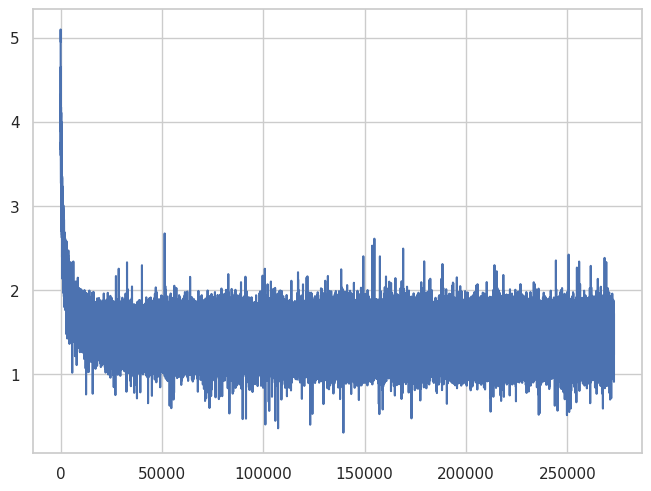

In [13]:
model = train_model(train_loader)

## Eval

In [40]:
import torch.utils.data as data

def evaluate(model: nn.Module, data_loader: data.DataLoader, device: torch.device):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in data_loader:
            X = batch[0].to(device)
            pred = model(X).squeeze(dim=1).cpu()
            predictions.append(pred)

    return torch.cat(predictions).numpy()

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = evaluate(model, test_loader, device)

results_df = pd.DataFrame(results, columns=['Predicted_cnt'])
results_df.to_csv('results.csv', index=False)

In [48]:
def calc_error(model: nn.Module, data_loader: data.DataLoader, loss_module: nn.Module, device: torch.device):
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for batch in data_loader:
            X = batch[0].to(device)
            pred = model(X).squeeze(dim=1)
            predictions.append(pred)
            if len(batch) > 1:
                Y = batch[1].to(device)
                targets.append(Y.squeeze())

    if not targets:
        raise ValueError("Podany DataLoader nie zawiera etykiet (Y). Nie można obliczyć błędu.")

    Y_pred_tensor = torch.cat(predictions)
    Y_tensor = torch.cat(targets)

    return loss_module(Y_pred_tensor, Y_tensor).item()

In [49]:
train_error = calc_error(model, train_loader, torch_rmsle, device)
val_error = calc_error(model, validation_loader, torch_rmsle, device)
val_error = calc_error(model, test_loader, torch_rmsle, device)

print(f"Train (RMSLE): {train_error:.4f}")
print(f"Val (RMSLE): {val_error:.4f}")
print(f"Test (RMSLE): {val_error:.4f}")

RuntimeError: zero-dimensional tensor (at position 68) cannot be concatenated

In [24]:
print(f"Test accurancy: {test_acc}, Validation accurancy: {val_acc}")

NameError: name 'test_acc' is not defined